## Глубокое обучение

#### Инициализация Keras

В качестве бэкенда используется pytorch

Бэкенд должен указываться до импорта keras

Для ускорения GPU от AMD можно попробовать заменить пакет torch на torch-directml

In [1]:
import os

os.environ["KERAS_BACKEND"] = "torch"
import keras
import torch

print(keras.__version__)

device = "cpu"
keras.utils.set_random_seed(42)

if torch.backends.mps.is_available():
    device = "mps"
    print("Ускорение GPU Apple Metal активно")
elif torch.cuda.is_available():
    device = "cuda"
    print("Ускорение GPU NVIDIA CUDA активно")
else:
    try:
        import torch_directml
        device = torch_directml.device()
        print("Ускорение GPU AMD DirectML активно")
    except ImportError:
        print("Используется CPU")

3.14.0
Ускорение GPU Apple Metal активно


#### Функция для визуализации обучения модели

In [2]:
from typing import Any

import matplotlib.pyplot as plt


def plot_training_history(history: Any, metric: str="accuracy") -> None:  # noqa: ANN401
    """
    Визуализация кривых обучения.
    Параметры:
        history - объект, возвращённый model.fit()
        metric  - метрика для отображения ('accuracy' или 'loss')
    """
    _, axes = plt.subplots(1, 2, figsize=(12, 4))

    # График потерь
    axes[0].plot(history.history["loss"], label="Train loss", linewidth=2)
    axes[0].plot(history.history["val_loss"], label="Validation loss", linewidth=2)
    axes[0].set_title("Loss over epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    # График метрики (accuracy или mae)
    if metric == "accuracy":
        train_metric = history.history["accuracy"]
        val_metric = history.history["val_accuracy"]
        ylabel = "Accuracy"
    else:
        train_metric = history.history[metric]
        val_metric = history.history["val_" + metric]
        ylabel = metric.capitalize()

    axes[1].plot(train_metric, label=f"Train {metric}", linewidth=2)
    axes[1].plot(val_metric, label=f"Validation {metric}", linewidth=2)
    axes[1].set_title(f"{ylabel} over epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel(ylabel)
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

### Классификация

#### Загрузка набора данных для задачи классификации

База данных MNIST (сокращение от "Modified National Institute of Standards and Technology") — объёмная база данных образцов рукописного написания цифр. База данных является стандартом, предложенным Национальным институтом стандартов и технологий США с целью обучения и сопоставления методов распознавания изображений с помощью машинного обучения в первую очередь на основе нейронных сетей. Данные состоят из заранее подготовленных примеров изображений, на основе которых проводится обучение и тестирование систем.

База данных MNIST содержит 60000 изображений для обучения и 10000 изображений для тестирования.

In [3]:
from keras.datasets import mnist

(X_train_raw, y_train_raw), (X_valid_raw, y_valid_raw) = mnist.load_data()

#### Отображение данных

Образцы из набора прошли сглаживание и приведены к серому полутоновому изображению размером 28x28 пикселей.

Под каждым изображением представлено соответствующее ему значение целевого признака (класс).

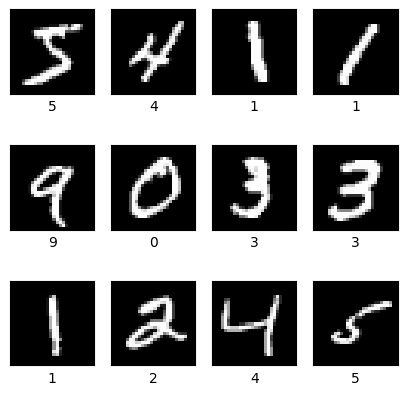

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(5, 5))
for k in range(12):
    current_axes = axes[k % 3][k % 4]
    current_axes.imshow(X_train_raw[k], cmap='grey')
    current_axes.get_xaxis().set_ticks([])
    current_axes.get_yaxis().set_ticks([])
    current_axes.set_xlabel(y_train_raw[k])
plt.show()

#### Предобработка данных

Количество классов - 10 (от 0 до 9).

Все изображения из X трансформируются в векторы длиной 784 (28*28) признака и нормализуются.

Для целевых признаков применяется унитарное кодирование в бинарные векторы длиной 10 (нормализация).

In [5]:
n_classes = 10

X_train = X_train_raw.reshape(60000, 784).astype("float32") / 255
X_valid = X_valid_raw.reshape(10000, 784).astype("float32") / 255
y_train = keras.utils.to_categorical(y_train_raw, n_classes)
y_valid = keras.utils.to_categorical(y_valid_raw, n_classes)

display(X_train[0])
display(y_train[0])

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

#### Проектирование архитектуры простой ИНС

Сеть состоит из:
- входного слоя с 784 входами (InputLayer);
- скрытого полносвязного слоя с 64 sigmoid-нейронами (dense_2);
- выходного слоя с 10 softmax-нейронами (многоклассовая классификация) (dense_3).

Количество параметров в слоях:
- dense_2: 784 * 64 + 64 = 50 176 + 64 = 50 240. У каждого из 64 нейронов 784 входа с 784 параметрами (w * x) + 64 смещения (b).
- dense_3: 64 * 10 + 10 = 640 + 10 = 650.

Всего параметров: 50 240 + 650 = 50 890.

Все параметры настраиваются в процессе обучения.

In [6]:
from keras.layers import Dense, InputLayer
from keras.models import Sequential

simple_model = Sequential()
simple_model.add(InputLayer(shape=(28*28,)))
simple_model.add(Dense(64, activation="sigmoid"))
simple_model.add(Dense(n_classes, activation="softmax"))
simple_model.summary()

simple_model.to(device)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

<Sequential name=sequential, built=True>

#### Обучение простой модели

Функция стоимости: MSE (квадратичная функция)

Оптимизатор: стохастический градиентный спуск (SGD)

Скорость обучения: 0.01

Количество эпох: 200

Размер пакета: 128

Всего пакетов: 60 000 / 128 = 468.75 (468 пакетов по 128 изображений и 1 пакет с 96 изображениями)

Метрика оценки качества: accuracy

Оценка качества и стоимость на обучающей выборке:\
accuracy: 0.4650 - loss: 0.0849

Оценка качества и стоимость на тестовой выборке:\
val_accuracy: 0.4703 - val_loss: 0.0845

In [7]:
from keras.optimizers import SGD

simple_model.compile(
    loss="mean_squared_error",
    optimizer=SGD(learning_rate=0.01),
    metrics=["accuracy"],
)

sm_history = simple_model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=200,
    validation_data=(X_valid, y_valid),
)

Epoch 1/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.1125 - loss: 0.0931 - val_accuracy: 0.1141 - val_loss: 0.0913
Epoch 2/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.1165 - loss: 0.0907 - val_accuracy: 0.1255 - val_loss: 0.0901
Epoch 3/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1307 - loss: 0.0899 - val_accuracy: 0.1405 - val_loss: 0.0895
Epoch 4/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1464 - loss: 0.0894 - val_accuracy: 0.1597 - val_loss: 0.0891
Epoch 5/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1654 - loss: 0.0890 - val_accuracy: 0.1824 - val_loss: 0.0888
Epoch 6/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.1855 - loss: 0.0887 - val_accuracy: 0.2046 - val_loss: 0.0884
Epoch 7/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.2080 - loss: 0.0884 - val_accuracy: 0.2337 - val_loss: 0.0882
Epoch 8/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.2344 - loss: 0.0881 - val_accu

**Важное замечание:** в учебных целях начала намеренно используется **неподходящая** для классификации функция потерь на основе среднеквадратичной ошибки (MSE).

MSE используется для:
1. Иллюстрации, как падает качество и замедляется обучение при неправильном выборе функции потерь.
2. На следующем шаге MSE будет заменена на cross‑entropy для повышения качества модели.

Обычно для многоклассовой классификации применяют перекрестную энтропию (categorical_crossentropy). 

**Не повторяйте эту ошибку в реальных проектах!**

#### Оценка качества простой модели

Лучшее качество модели чуть больше 86 %

In [8]:
simple_model.evaluate(X_valid, y_valid)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8651 - loss: 0.0270


[0.027000633999705315, 0.8651000261306763]

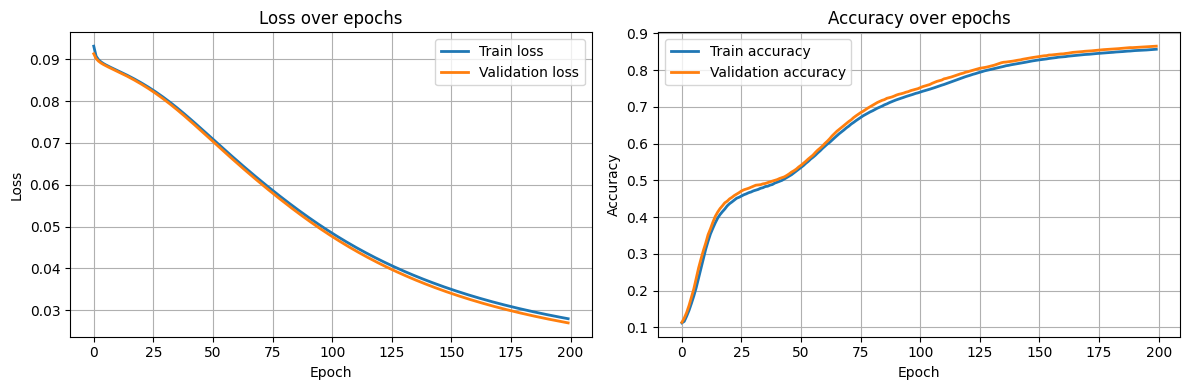

In [9]:
plot_training_history(sm_history, metric="accuracy")

#### Проектирование архитектуры более сложной ИНС

Добавлен дополнительный скрытый полносвязный слой

Все скрытые слои используют ReLU-нейроны

In [10]:
difficult_model = Sequential()
difficult_model.add(InputLayer(shape=(28 * 28,)))
difficult_model.add(Dense(64, activation="relu"))
difficult_model.add(Dense(64, activation="relu"))
difficult_model.add(Dense(10, activation="softmax"))
difficult_model.summary()

difficult_model.to(device)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

<Sequential name=sequential_1, built=True>

#### Обучение более сложной модели

Функция стоимости изменена на перекрестную энтропию (лучше подходит для классификации)

Количество эпох уменьшено с 200 до 20

In [11]:
difficult_model.compile(
    loss="categorical_crossentropy",
    optimizer=SGD(learning_rate=0.1),
    metrics=["accuracy"],
)

dm_history = difficult_model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_data=(X_valid, y_valid),
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8651 - loss: 0.4687 - val_accuracy: 0.9248 - val_loss: 0.2626
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9319 - loss: 0.2323 - val_accuracy: 0.9444 - val_loss: 0.1901
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9471 - loss: 0.1807 - val_accuracy: 0.9537 - val_loss: 0.1570
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9560 - loss: 0.1493 - val_accuracy: 0.9578 - val_loss: 0.1437
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9624 - loss: 0.1278 - val_accuracy: 0.9602 - val_loss: 0.1295
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9669 - loss: 0.1114 - val_accuracy: 0.9643 - val_loss: 0.1167
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9704 - loss: 0.0985 - val_accuracy: 0.9673 - val_loss: 0.1078
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9744 - loss: 0.0876 - val_accuracy: 0

#### Оценка качества более сложной модели

Лучшее качество модели чуть больше 97 %

При этом количество эпох обучения значительно сократилось (с 200 до 20).

In [12]:
display("MSE и 200 эпох", simple_model.evaluate(X_valid, y_valid))
display("categorical_crossentropy и 20 эпох", difficult_model.evaluate(X_valid, y_valid))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8651 - loss: 0.0270


'MSE и 200 эпох'

[0.027000633999705315, 0.8651000261306763]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9758 - loss: 0.0839


'categorical_crossentropy и 20 эпох'

[0.08392783254384995, 0.9757999777793884]

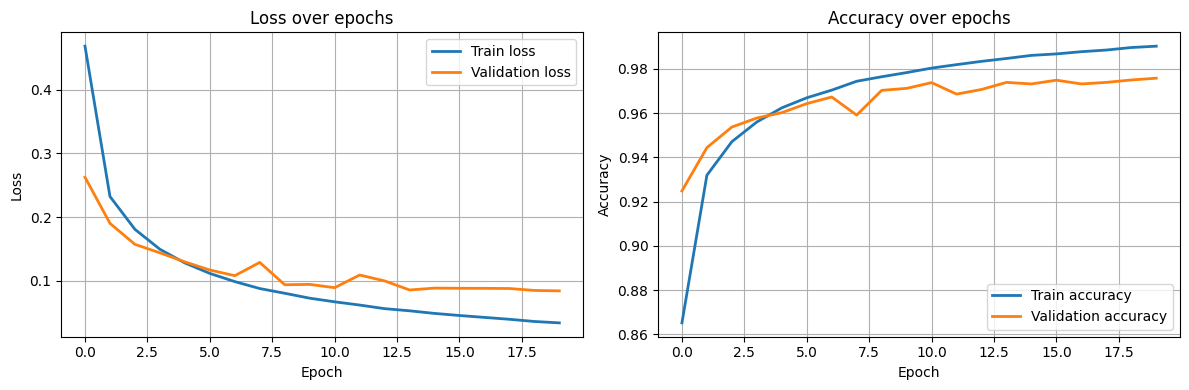

In [13]:
plot_training_history(dm_history, metric="accuracy")

#### Проектирование архитектуры глубокой ИНС

В ИНС теперь три скрытых полносвязных слоя с ReLU-нейронами

Для выходов каждого скрытого слоя используется пакетная нормализация

Для последнего скрытого слоя применяется прореживание, при котором отключается 20 % случайных нейронов

Keras автоматически корректирует значения (умножает входы на 0.8)

In [14]:
from keras.layers import BatchNormalization, Dropout

deep_model = Sequential()
deep_model.add(InputLayer(shape=(28 * 28,)))
deep_model.add(Dense(64, activation="relu"))
deep_model.add(BatchNormalization())
deep_model.add(Dense(64, activation="relu"))
deep_model.add(BatchNormalization())
deep_model.add(Dense(64, activation="relu"))
deep_model.add(BatchNormalization())
deep_model.add(Dropout(0.2))
deep_model.add(Dense(10, activation="softmax"))
deep_model.summary()

deep_model.to(device)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,978 (234.29 KB)

 Trainable params: 59,594 (232.79 KB)

 Non-trainable params: 384 (1.50 KB)

<Sequential name=sequential_2, built=True>

#### Обучение глубокой модели

Вместо SGD используется оптимизатор Adam

In [15]:
deep_model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

dpm_history = deep_model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_data=(X_valid, y_valid),
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8878 - loss: 0.3772 - val_accuracy: 0.9524 - val_loss: 0.1583
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9545 - loss: 0.1511 - val_accuracy: 0.9644 - val_loss: 0.1121
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9670 - loss: 0.1104 - val_accuracy: 0.9695 - val_loss: 0.0987
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9725 - loss: 0.0889 - val_accuracy: 0.9719 - val_loss: 0.0957
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9757 - loss: 0.0775 - val_accuracy: 0.9735 - val_loss: 0.0856
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9791 - loss: 0.0649 - val_accuracy: 0.9707 - val_loss: 0.0917
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9820 - loss: 0.0564 - val_accuracy: 0.9762 - val_loss: 0.0859
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9838 - loss: 0.0500 - val_accu

#### Оценка качества глубокой модели

Лучшее качество модели чуть больше 97 %

Качество модели незначительно улучшилось за счет улучшения архитектуры сети и смены оптимизатора

In [16]:
deep_model.evaluate(X_valid, y_valid)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9770 - loss: 0.0915


[0.0915272906422615, 0.9769999980926514]

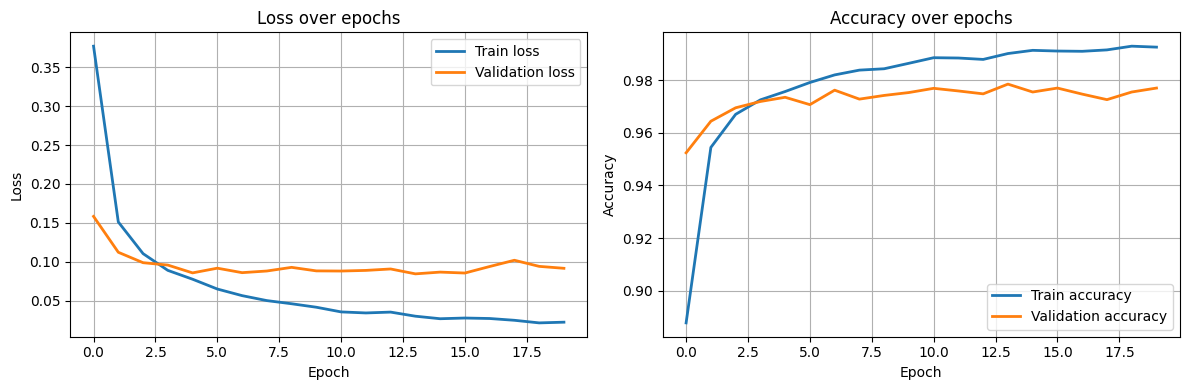

In [17]:
plot_training_history(dpm_history, metric="accuracy")

### Регрессия

#### Загрузка данных для задачи регрессии

Набор данных о жилье в Бостоне собран Службой переписи населения США.

Входные признаки:
- CRIM — уровень преступности на душу населения по районам;
- ZN — доля жилых земель, отведенных под участки площадью более 25 000 кв. футов;
- INDUS — доля неторговых акров в городе;
- CHAS — 1, если участок граничит с рекой; 0 в противном случае;
- NOX — концентрация оксидов азота;
- RM — среднее количество комнат в помещении;
- AGE — доля домов, построенных до 1940 года;
- DIS — взвешенные расстояния до пяти центров занятости Бостона;
- RAD — индекс доступности радиальных автомагистралей;
- TAX — ставка налога на имущество на полную стоимость;
- PTRATIO — соотношение учеников и учителей по районам;
- B — доля чернокожих по районам;
- LSTAT — % населения с более низким статусом.

Целевой признак:
- MEDV — медианная стоимость домов в тысячах долларов США.

Данные уже предобработаны

In [18]:
from keras.datasets import boston_housing

(X_train_reg, y_train_reg), (X_valid_reg, y_valid_reg) = boston_housing.load_data()

display(X_train_reg)
display(y_train_reg)

array([[1.23247e+00, 0.00000e+00, 8.14000e+00, ..., 2.10000e+01,
        3.96900e+02, 1.87200e+01],
       [2.17700e-02, 8.25000e+01, 2.03000e+00, ..., 1.47000e+01,
        3.95380e+02, 3.11000e+00],
       [4.89822e+00, 0.00000e+00, 1.81000e+01, ..., 2.02000e+01,
        3.75520e+02, 3.26000e+00],
       ...,
       [3.46600e-02, 3.50000e+01, 6.06000e+00, ..., 1.69000e+01,
        3.62250e+02, 7.83000e+00],
       [2.14918e+00, 0.00000e+00, 1.95800e+01, ..., 1.47000e+01,
        2.61950e+02, 1.57900e+01],
       [1.43900e-02, 6.00000e+01, 2.93000e+00, ..., 1.56000e+01,
        3.76700e+02, 4.38000e+00]], shape=(404, 13))

array([15.2, 42.3, 50. , 21.1, 17.7, 18.5, 11.3, 15.6, 15.6, 14.4, 12.1,
       17.9, 23.1, 19.9, 15.7,  8.8, 50. , 22.5, 24.1, 27.5, 10.9, 30.8,
       32.9, 24. , 18.5, 13.3, 22.9, 34.7, 16.6, 17.5, 22.3, 16.1, 14.9,
       23.1, 34.9, 25. , 13.9, 13.1, 20.4, 20. , 15.2, 24.7, 22.2, 16.7,
       12.7, 15.6, 18.4, 21. , 30.1, 15.1, 18.7,  9.6, 31.5, 24.8, 19.1,
       22. , 14.5, 11. , 32. , 29.4, 20.3, 24.4, 14.6, 19.5, 14.1, 14.3,
       15.6, 10.5,  6.3, 19.3, 19.3, 13.4, 36.4, 17.8, 13.5, 16.5,  8.3,
       14.3, 16. , 13.4, 28.6, 43.5, 20.2, 22. , 23. , 20.7, 12.5, 48.5,
       14.6, 13.4, 23.7, 50. , 21.7, 39.8, 38.7, 22.2, 34.9, 22.5, 31.1,
       28.7, 46. , 41.7, 21. , 26.6, 15. , 24.4, 13.3, 21.2, 11.7, 21.7,
       19.4, 50. , 22.8, 19.7, 24.7, 36.2, 14.2, 18.9, 18.3, 20.6, 24.6,
       18.2,  8.7, 44. , 10.4, 13.2, 21.2, 37. , 30.7, 22.9, 20. , 19.3,
       31.7, 32. , 23.1, 18.8, 10.9, 50. , 19.6,  5. , 14.4, 19.8, 13.8,
       19.6, 23.9, 24.5, 25. , 19.9, 17.2, 24.6, 13

#### Проектирование ИНС для задачи регрессии

Для решения задачи регрессии в выходном слое используются нейроны с линейной функцией активации

Создавать более сложную архитектуру не имеет смысла, так как в наборе данных мало признаков

In [19]:
reg_model = Sequential()
reg_model.add(InputLayer(shape=(13,)))
reg_model.add(Dense(32, activation="relu"))
reg_model.add(BatchNormalization())
reg_model.add(Dense(16, activation="relu"))
reg_model.add(BatchNormalization())
reg_model.add(Dropout(0.2))
reg_model.add(Dense(1, activation="linear"))
reg_model.summary()

reg_model.to(device)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,089 (4.25 KB)

 Non-trainable params: 96 (384.00 B)

<Sequential name=sequential_3, built=True>

#### Обучение модели для регрессии

Функция стоимости: MSE (лучше подходит для задачи регрессии)

In [21]:
reg_model.compile(
    loss="mean_squared_error",
    optimizer="adam",
    metrics=["mae"],
)

rm_history = reg_model.fit(
    X_train_reg,
    y_train_reg,
    batch_size=16,
    epochs=32,
    validation_data=(X_valid_reg, y_valid_reg),
)

Epoch 1/32
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 308.2154 - mae: 16.5688 - val_loss: 425.6067 - val_mae: 19.6932
Epoch 2/32
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 286.2662 - mae: 15.9869 - val_loss: 379.4998 - val_mae: 18.5306
Epoch 3/32
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 262.3981 - mae: 15.4162 - val_loss: 374.2937 - val_mae: 18.3681
Epoch 4/32
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 245.5153 - mae: 14.8902 - val_loss: 335.5980 - val_mae: 17.2870
Epoch 5/32
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 233.7295 - mae: 14.4060 - val_loss: 343.8206 - val_mae: 17.4458
Epoch 6/32
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 215.1584 - mae: 13.5919 - val_loss: 308.9678 - val_mae: 16.5436
Epoch 7/32
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 202.6919 - mae: 13.2194 - val_loss: 296.9109 - val_mae: 16.1796
Epoch 8/32
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 192.2029 - mae: 12.7222 - val_loss: 247.1044 - val_mae: 14.6896
Epoch 9/32
26/26

#### Оценка качества модели для регрессии

Средняя ошибка на тестовой выборке чуть больше 3500 долларов

In [22]:
reg_results = reg_model.evaluate(X_valid_reg, y_valid_reg)
display(reg_results)
print(f"Средняя ошибка: {reg_results[1] * 1000:.2f} долларов")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 32.7595 - mae: 3.5158 


[32.759517669677734, 3.51580810546875]

Средняя ошибка: 3515.81 долларов


In [23]:
import numpy as np

y_hat = reg_model.predict(np.reshape(X_valid_reg[42], [1, 13]))
display(y_hat[0][0])
display(y_valid_reg[42])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


np.float32(13.965206)

np.float64(14.1)

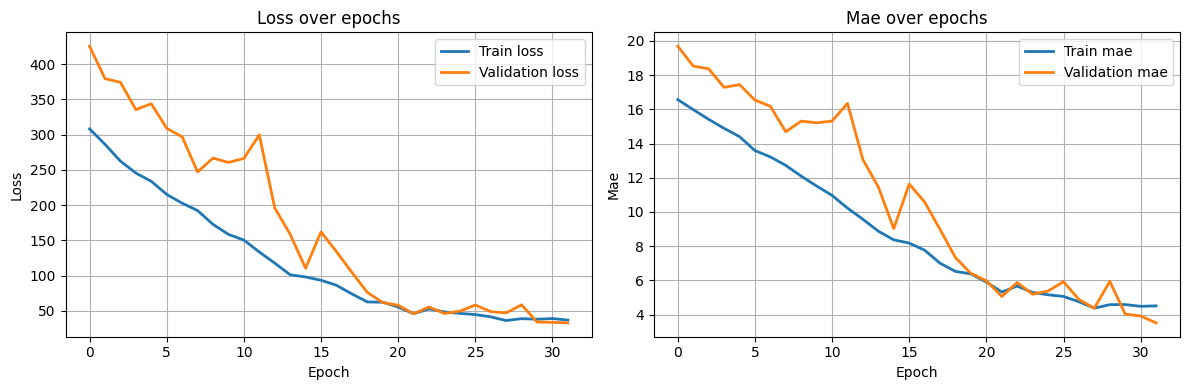

In [25]:
plot_training_history(rm_history, metric="mae")